# Check the Thermal-Density Output for DiskMINT

In [ ]:
# %matplotlib widget
%matplotlib inline
%reload_ext autoreload
%autoreload 2

import datetime, os, sys, copy

import numpy as np
import pandas as pd

from astropy.io import fits
import astropy.units as u
import astropy.constants as C

import tqdm

# for interpolate
from scipy import interpolate
from scipy.optimize import curve_fit

import matplotlib
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator
import cmasher as cmr

style = [
    # 'seaborn-ticks',
    {
        'figure.dpi': 300,
        'figure.figsize': (3.5, 3.5 / 1.618),
        'font.size': 12,  # 12
        'image.cmap': 'inferno',
        'font.family': 'serif',
        'font.serif': ['Times', 'Times New Roman'] + plt.rcParams['font.serif'],
        'xtick.top': True,
        'xtick.direction': 'out',
        'ytick.right': True,
        'ytick.direction': 'out',
        'mathtext.fontset': 'cm'
        }]

plt.style.use(style)

import diskmint.model as model
import diskmint.disk_density as dd
import diskmint.constants as const
import diskmint.modelgrid as modelgrid
import diskmint.dustopac as dustopac
import diskmint.execute as exe

## Import the utils for this work

In [14]:
# navigate to the work direcotry

work_dir = os.getcwd()
working_dir = work_dir

os.chdir(work_dir)
print(os.getcwd())
sys.path.append(os.getcwd())

utils_dir = os.path.join(work_dir, "..", "..", "example_utils")
sys.path.append(utils_dir)
import diskmint_utils as utils

/Users/dingshandeng/github/0-Project_Disk_Models/DiskMINT/examples/example_diskmint_models/example_diskmint_model_0p5ms_star


## Select the Model

In [16]:
output_dir = os.path.join(work_dir, 'output')
model_dirs = sorted([d for d in os.listdir(output_dir)
                     if os.path.isdir(os.path.join(output_dir, d))])

print(model_dirs)

['diskmint_similar_to_HH30_example_20260223_t0_mdust1p0e-04ms_gtd100_pla3p50_amax0p10']


In [17]:
# --- change here to select the model dir to read in ---

i_model_select = 0 # select the first model in the model_dirs
model_name_in_figure = "a disk around 0.5 ms star similar to HH30" # choose a name to show in the figure, can be different from the model_name which is used to read in the data

# --- end changing here ---

model_name = model_dirs[i_model_select]

output_for_this_model_dir = os.path.join(output_dir, model_name)

para = model.Parameters()
para.read_parameters_from_csv(directory=output_for_this_model_dir, filename=model_name+'_parameters', extension='.csv')

specific_g2d_ref_name = os.path.join(work_dir, 'ratio_g2d_reference.dat')
if os.path.exists(specific_g2d_ref_name):
    print('read the specific g2d ref file %s'%(specific_g2d_ref_name))
    ratio_g2d_reference = np.loadtxt(specific_g2d_ref_name)

mint = model.Mint(para, file_dir=output_for_this_model_dir)
mint.setup_dust_info(para, bool_savefile=False)

Used the powerlow for surface density and tapering-off: -1.000; 1.000
Used the Method 1 to setup Hp, with Hp100 = 10.000
the g2d ratio set up is a constant (float or float64 or integer), with ratio_g2d=100.00
input primary mdiskd: 1.000e-04 [ms]
setup primary mdiskd: 1.000e-04 [ms]
input secondary mdiskd_2: 0.000e+00 [ms]
setup secondary mdiskd_2: 0.000e+00 [ms]
setup total mdiskd: 1.000e-04 [ms]
setup mdiskg: 1.000e-02 [ms]
setup gtd: 1.000e+02
Computing Frations of Dust Species Assuming in the same Slope


1

## Reading in the model results

In [19]:
os.chdir(output_for_this_model_dir)
# os.chdir(file_dir_readin)
print('reading radmc3d format files from')
print(os.getcwd())

# also read in gastemperature
# you can use radmc3dPy to read in the radmc3d format files, but here we use the readData function in modelgrid which is more customized for our use and can read in more data (e.g., gas temperature)
# dustdens = radmc3dPy.analyze.readData(dtemp=True, ddens=True, gtemp=True)
dustdens = modelgrid.readData(dtemp=True, ddens=True, gtemp=True)

rhodust = dustdens.rhodust.copy()
rhodust_all = rhodust.sum(3).copy()

ratio_g2d_grid_file = 'ratio_g2d_grid.dat'
if os.path.exists(ratio_g2d_grid_file):
    print('read in the reference ratio_g2d_grid from %s'%(ratio_g2d_grid_file))
    ratio_g2d_grid_readin = dd.load_3dgrid_from_dat(ratio_g2d_grid_file)
    ratio_g2d_grid = ratio_g2d_grid_readin
    ratio_g2d_grid[ratio_g2d_grid == np.inf] = np.nan

    mint.ratio_g2d = ratio_g2d_grid

rhogas = rhodust_all * mint.ratio_g2d
rhogas[rhogas <= const.mu] = const.mu

ngas   = rhogas / const.mu
nr     = dustdens.grid.nx
ntheta = dustdens.grid.ny
nphi   = dustdens.grid.nz
rc     = dustdens.grid.x
thetac = dustdens.grid.y
phic   = dustdens.grid.z
qq     = np.meshgrid(rc,thetac,phic,indexing='ij')
rr     = qq[0] # Spherical R 
tt     = qq[1] # Angle with z axis ( = pi/2 for the z=0 axis)
zr     = np.pi/2.e0 - qq[1]
zz     = np.sin(zr)*rr

# Plot the Tdust
# 
# Read dust temperature
#
Tdust = dustdens.dusttemp.copy()
#
# Read gas temperature
#
Tgas_0 = dustdens.gastemp.copy()

# test the total mass to see whether the mass is conservative to what it should be set upackage_position
mdust_set = (rhodust_all * mint.vol).sum(0).sum(0).sum(0) * 2
mgas_set = (rhogas * mint.vol).sum(0).sum(0).sum(0) * 2
mgas_set_2 = (rhodust_all * mint.vol * mint.ratio_g2d).sum(0).sum(0).sum(0) * 2

print('the read in radmc3d mdust = %.2e [ms]'%(mdust_set/const.ms))
print('the read in radmc3d mgas = %.2e [ms]'%(mgas_set/const.ms))
print('the read in radmc3d mgas (set by mdust * gtd) = %.2e [ms]'%(mgas_set_2/const.ms))
print('the set up gas-to-dust mass ratio = %.2f'%(mgas_set/mdust_set))

# plt.plot(ratio_g2d_grid_readin[:, -1, 0])

reading radmc3d format files from
/Users/dingshandeng/github/0-Project_Disk_Models/DiskMINT/examples/example_diskmint_models/example_diskmint_model_0p5ms_star/output/diskmint_similar_to_HH30_example_20260223_t0_mdust1p0e-04ms_gtd100_pla3p50_amax0p10
Reading amr_grid.inp
Reading wavelength_micron.inp
Reading dust_density.inp
Reading dust_temperature.dat
Reading gas temperature
read in the reference ratio_g2d_grid from ratio_g2d_grid.dat
the read in radmc3d mdust = 1.00e-04 [ms]
the read in radmc3d mgas = 1.00e-02 [ms]
the read in radmc3d mgas (set by mdust * gtd) = 1.00e-02 [ms]
the set up gas-to-dust mass ratio = 100.00


## Plot surface density (Sigma)

(215,)
(215,)
(215,)


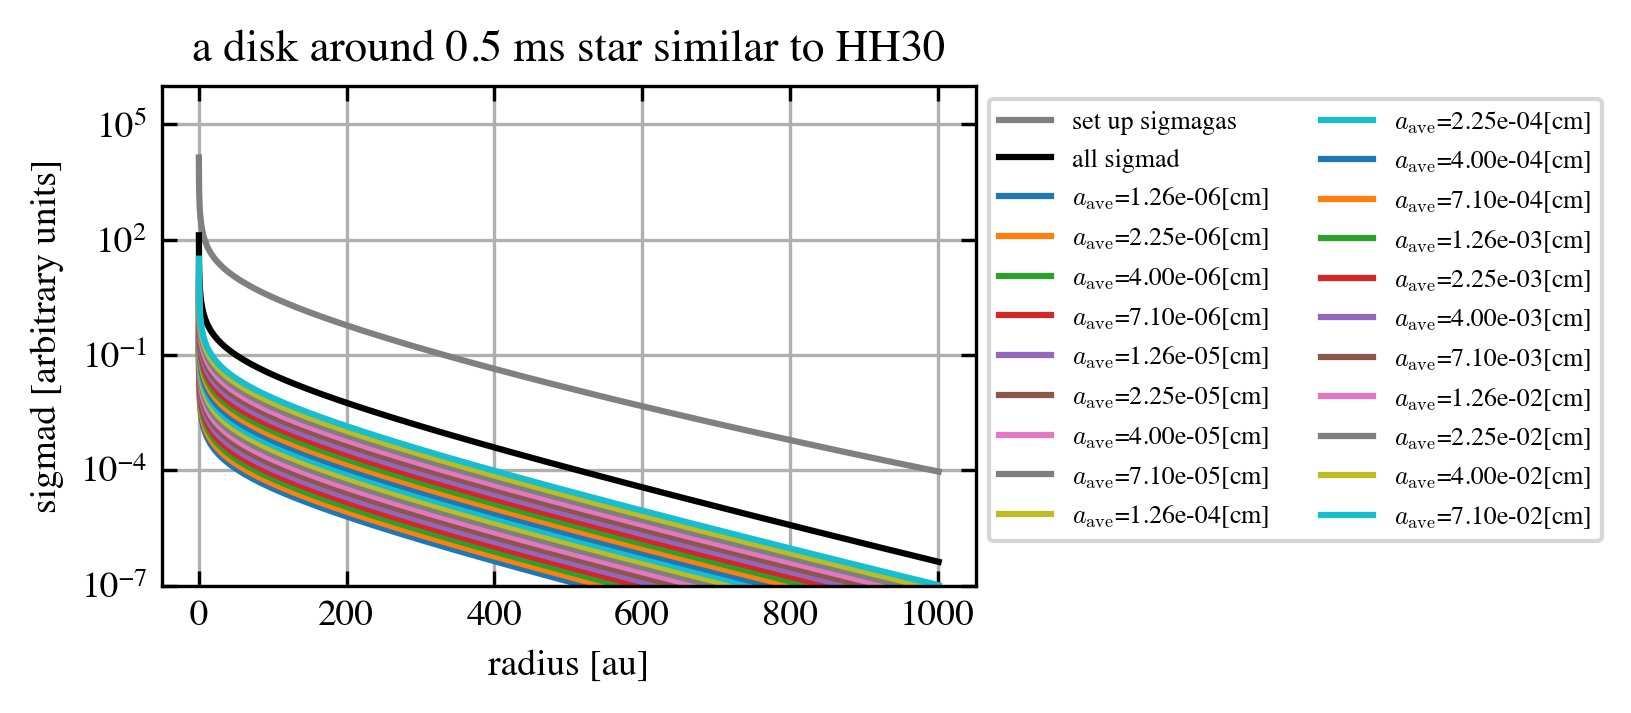

In [21]:
from scipy.interpolate import interp1d

def get_sigma_interval(rho_t):
    trapz = np.trapezoid if hasattr(np, "trapezoid") else np.trapz

    rho_slice = np.asarray(rho_t)[:, :, 0]
    z_slice = -zz[:, :, 0]

    integral_rho_t = trapz(rho_slice, x=z_slice, axis=1)
    dsigma_t = 4.0 * np.pi * integral_rho_t

    return dsigma_t

# sigmag_t = dsigma_t # rhogas.sum(1)
sigmag_t = get_sigma_interval(rhogas)
print(sigmag_t.shape)

sigmad_0_t = get_sigma_interval(rhodust[:, :, :, 0])
print(sigmad_0_t.shape)
sigmad_m1_t = get_sigma_interval(rhodust[:, :, :, -1])
print(sigmad_m1_t.shape)

nrspec = len(mint.a_ave)

fig = plt.figure(dpi=300)
ax  = fig.add_subplot(1,1,1)

ax.plot(mint.rc/const.au, sigmag_t, label='set up sigmagas', c='grey')

# a scale factor to check whether the g2d makes sense as a quick sanity check.
scale_factor = 1.0
ax.plot(mint.rc/const.au, get_sigma_interval(rhodust_all[:, :, :]) * scale_factor, label='all sigmad', c='k')

for i_nr_spec in np.arange(0, nrspec, 1):
    ax.plot(mint.rc/const.au, get_sigma_interval(rhodust[:, :, :, i_nr_spec]) * scale_factor, label=r'$a_{\rm ave}$=%.2e[cm]'%(mint.a_ave[i_nr_spec]))

ax.set_xlabel('radius [au]')
ax.set_ylabel('sigmad [arbitrary units]')

# ax.set_xscale('log')
ax.set_yscale('log')

ax.grid()

# ax.set_ylim(1e12, 1e20)
ax.set_ylim(1e-7, 1e6)

ax.legend(loc='upper left', bbox_to_anchor=(1.0, 1.0), ncol=2, fontsize='x-small')

ax.set_title(model_name_in_figure)

plt.show()

## Show the density map of the gas

### The gas density and temperature

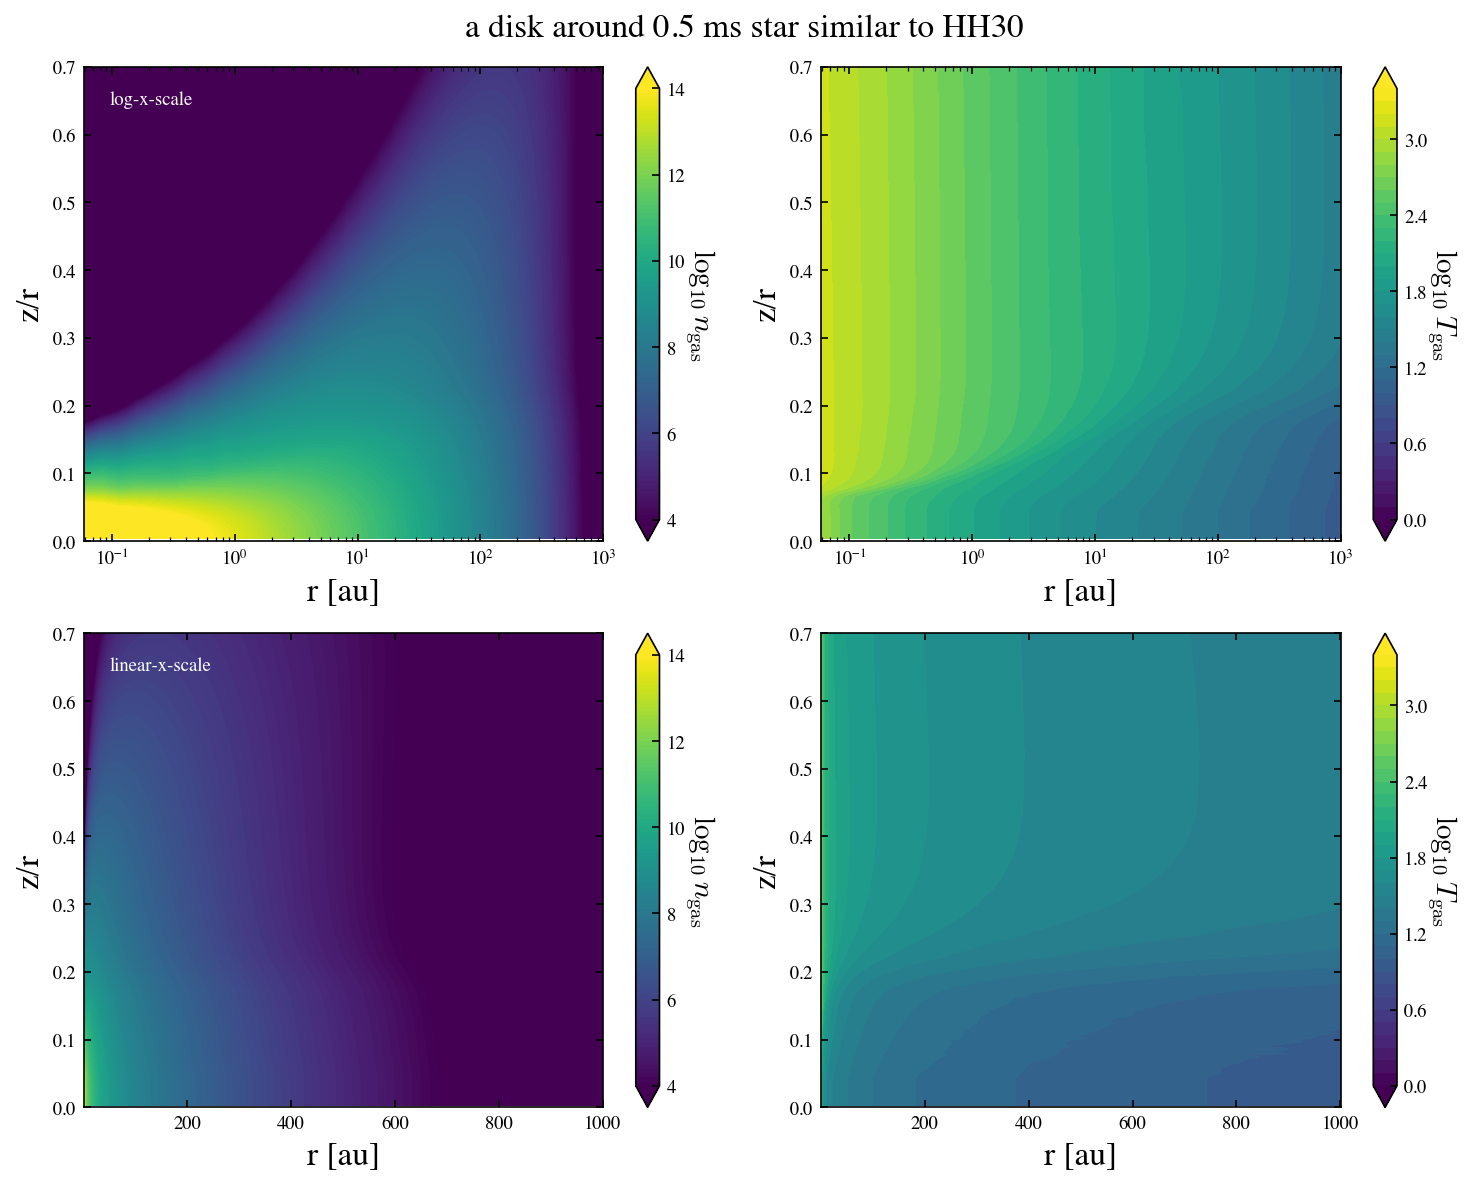

In [22]:
ncol = 2
nrow = 2

fig=plt.figure(dpi=150, figsize = (5*ncol, 4*nrow))

lim = np.arange(4, 14.1, 0.1) # 4, 18.1, 0.1
ticksrange = np.arange(4, 16, 2) # 4, 20, 2

lim_Tgas = np.arange(0, 3.5, 0.1)
ticksrange_Tgas = np.arange(0, 3.6, 0.6)

ylim_t = (0, 0.7)

fig.suptitle(model_name_in_figure, fontsize = 16)

######################################

plt.subplot(nrow,ncol,1)

# plt.title('Spherical Coordinate', fontsize = 12)

plt.annotate("log-x-scale", xy=(0.05, 0.95), xycoords='axes fraction', fontsize="medium", ha='left', va='top', color='w')

c = plt.contourf(rc/const.au, np.pi/2 - thetac, np.log10((rhogas[:,:,0]/const.mu).T), lim, zorder = 1, cmap = 'viridis', extend = 'both')

cb = plt.colorbar(c, ticks=ticksrange)
cb.set_label(r'$\log_{10}{n_{\mathrm{gas}}}$', labelpad = 15, y = 0.5, rotation=270., fontsize = 14)

# plt.text(0.1, 0.6, r'$n_{\mathrm{gas}}$', fontsize = 15)

plt.xlabel('r [au]', fontsize = 16)
plt.ylabel(r'z/r', fontsize = 16)
plt.xscale('log')

plt.ylim(ylim_t)

######################################

plt.subplot(nrow,ncol,2)

# plt.title('Spherical Coordinate', fontsize = 12)

c = plt.contourf(rc/const.au, np.pi/2 - thetac, np.log10((Tgas_0[:,:,0,0]).T), lim_Tgas, zorder = 1, cmap = 'viridis', extend = 'both')

cb = plt.colorbar(c, ticks=ticksrange_Tgas)
cb.set_label(r'$\log_{10}{T_{\mathrm{gas}}}$', labelpad = 15, y = 0.5, rotation=270., fontsize = 14)

# ctau = plt.contour(rc/const.au, np.pi/2 - thetac, np.log10((Tgas[:,:,0]).T), [np.log10(1500)],  colors='k', linestyles='solid')
# # manual_locations = [(0.2, 0.3), (1, 0.3), (50, 0.3), (200, 0.15)] 
# plt.clabel(ctau, inline=0, inline_spacing=40, colors = 'k', fontsize=9) # , fmt = '%1.0f K', manual = manual_locations)

plt.xlabel('r [au]', fontsize = 16)
plt.ylabel(r'z/r', fontsize = 16)
plt.xscale('log')

plt.ylim(ylim_t)

######################################

plt.subplot(nrow,ncol,3)

# plt.title('Spherical Coordinate', fontsize = 12)
plt.annotate("linear-x-scale", xy=(0.05, 0.95), xycoords='axes fraction', fontsize="medium", ha='left', va='top', color='w')

c = plt.contourf(rc/const.au, np.pi/2 - thetac, np.log10((rhogas[:,:,0]/const.mu).T), lim, zorder = 1, cmap = 'viridis', extend = 'both')

cb = plt.colorbar(c, ticks=ticksrange)
cb.set_label(r'$\log_{10}{n_{\mathrm{gas}}}$', labelpad = 15, y = 0.5, rotation=270., fontsize = 14)

# plt.text(0.1, 0.6, r'$n_{\mathrm{gas}}$', fontsize = 15)

plt.xlabel('r [au]', fontsize = 16)
plt.ylabel(r'z/r', fontsize = 16)
# plt.xscale('log')

plt.ylim(ylim_t)


# ######################################

plt.subplot(nrow,ncol,4)


# plt.title('Spherical Coordinate', fontsize = 12)

c = plt.contourf(rc/const.au, np.pi/2 - thetac, np.log10((Tgas_0[:,:,0,0]).T), lim_Tgas, zorder = 1, cmap = 'viridis', extend = 'both')
cb = plt.colorbar(c, ticks=ticksrange_Tgas)
cb.set_label(r'$\log_{10}{T_{\mathrm{gas}}}$', labelpad = 15, y = 0.5, rotation=270., fontsize = 14)

# mint.sigmad[:, :, 0].T

# lim_t = np.arange(-5, 2.1, 0.1)
# ticksrange_t = np.arange(-5, 2.5, 0.5)

# c = plt.contourf(rc/const.au, (np.pi/2 - thetac), np.log10(sigmagas[:, :, 0].T), lim_t, zorder = 1, cmap = 'viridis', extend = 'both')
# cb = plt.colorbar(c, ticks=ticksrange_t)
# cb.set_label(r'$\log_{10}{T_{\mathrm{gas}}}$', labelpad = 15, y = 0.5, rotation=270., fontsize = 14)

# ctau = plt.contour(rc/const.au, np.pi/2 - thetac, np.log10((Tgas[:,:,0]).T), [np.log10(1500)],  colors='k', linestyles='solid')
# # manual_locations = [(0.2, 0.3), (1, 0.3), (50, 0.3), (200, 0.15)] 
# plt.clabel(ctau, inline=0, inline_spacing=40, colors = 'k', fontsize=9) # , fmt = '%1.0f K', manual = manual_locations)

plt.xlabel('r [au]', fontsize = 16)
plt.ylabel(r'z/r', fontsize = 16)
# plt.xscale('log')

plt.ylim(ylim_t)

######################################

fig.tight_layout()
plt.show()

### the dust and gas

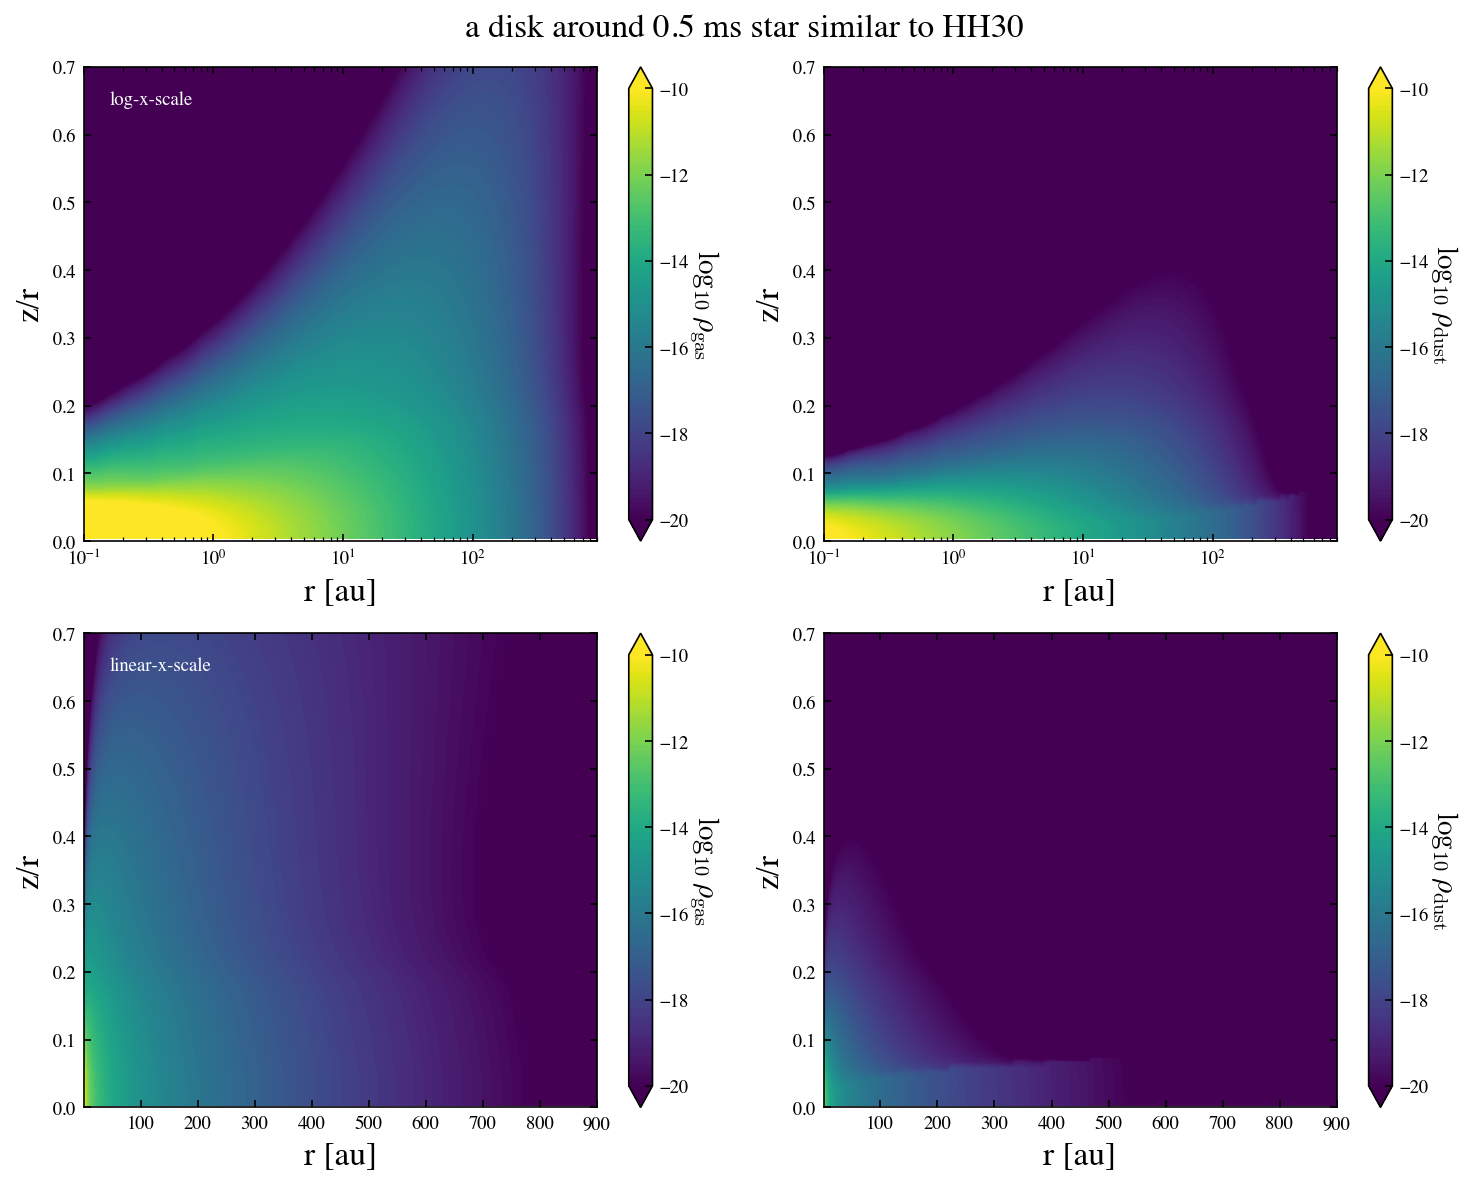

In [23]:
## Make a plot for the rhodust, rhogas and gas-to-dust mass ratio

ncol = 2
nrow = 2

fig=plt.figure(dpi=150, figsize = (5*ncol, 4*nrow))

lim = np.arange(4, 14.1, 0.1)-24 # 4, 18.1, 0.1
ticksrange = np.arange(4, 16, 2)-24 # 4, 20, 2

lim_gtd = np.arange(50, 151, 1)
ticksrange_gtd = np.arange(50, 200, 50)

# lim_Tgas = np.arange(0, 3.5, 0.1)
# ticksrange_Tgas = np.arange(0, 3.6, 0.6)

xlim_t = 0.1, 900
ylim_t = 0, 0.7 # 0.9

fig.suptitle(model_name_in_figure, fontsize = 16)

######################################

plt.subplot(nrow,ncol,1)

# plt.title('Spherical Coordinate', fontsize = 12)
plt.annotate("log-x-scale", xy=(0.05, 0.95), xycoords='axes fraction', fontsize="medium", ha='left', va='top', color='w')

c = plt.contourf(rc/const.au, np.pi/2 - thetac, np.log10((rhogas[:,:,0]).T), lim, zorder = 1, cmap = 'viridis', extend = 'both')

cb = plt.colorbar(c, ticks=ticksrange)
cb.set_label(r'$\log_{10}{\rho_{\mathrm{gas}}}$', labelpad = 15, y = 0.5, rotation=270., fontsize = 14)

# plt.text(0.1, 0.6, r'$n_{\mathrm{gas}}$', fontsize = 15)

plt.xlabel('r [au]', fontsize = 16)
plt.ylabel(r'z/r', fontsize = 16)
plt.xscale('log')

plt.xlim(xlim_t[0], xlim_t[1])
plt.ylim(ylim_t[0], ylim_t[1])

######################################

plt.subplot(nrow,ncol,ncol+1)

# plt.title('Spherical Coordinate', fontsize = 12)
plt.annotate("linear-x-scale", xy=(0.05, 0.95), xycoords='axes fraction', fontsize="medium", ha='left', va='top', color='w')

c = plt.contourf(rc/const.au, np.pi/2 - thetac, np.log10((rhogas[:,:,0]).T), lim, zorder = 1, cmap = 'viridis', extend = 'both')

cb = plt.colorbar(c, ticks=ticksrange)
cb.set_label(r'$\log_{10}{\rho_{\mathrm{gas}}}$', labelpad = 15, y = 0.5, rotation=270., fontsize = 14)

# plt.text(0.1, 0.6, r'$n_{\mathrm{gas}}$', fontsize = 15)

plt.xlabel('r [au]', fontsize = 16)
plt.ylabel(r'z/r', fontsize = 16)
# plt.xscale('log')

plt.xlim(xlim_t[0], xlim_t[1])
plt.ylim(ylim_t[0], ylim_t[1])

######################################

plt.subplot(nrow,ncol,2)

# plt.title('Spherical Coordinate', fontsize = 12)

c = plt.contourf(rc/const.au, np.pi/2 - thetac, np.log10((rhodust_all[:,:,0]).T), lim, zorder = 1, cmap = 'viridis', extend = 'both')

cb = plt.colorbar(c, ticks=ticksrange)
cb.set_label(r'$\log_{10}{\rho_{\mathrm{dust}}}$', labelpad = 15, y = 0.5, rotation=270., fontsize = 14)

# plt.text(0.1, 0.6, r'$n_{\mathrm{gas}}$', fontsize = 15)

plt.xlabel('r [au]', fontsize = 16)
plt.ylabel(r'z/r', fontsize = 16)
plt.xscale('log')

plt.xlim(xlim_t[0], xlim_t[1])
plt.ylim(ylim_t[0], ylim_t[1])

######################################

plt.subplot(nrow,ncol,ncol+2)

# plt.title('Spherical Coordinate', fontsize = 12)

c = plt.contourf(rc/const.au, np.pi/2 - thetac, np.log10((rhodust_all[:,:,0]).T), lim, zorder = 1, cmap = 'viridis', extend = 'both')

cb = plt.colorbar(c, ticks=ticksrange)
cb.set_label(r'$\log_{10}{\rho_{\mathrm{dust}}}$', labelpad = 15, y = 0.5, rotation=270., fontsize = 14)

# plt.text(0.1, 0.6, r'$n_{\mathrm{gas}}$', fontsize = 15)

plt.xlabel('r [au]', fontsize = 16)
plt.ylabel(r'z/r', fontsize = 16)
# plt.xscale('log')

plt.xlim(xlim_t[0], xlim_t[1])
plt.ylim(ylim_t[0], ylim_t[1])

######################################

fig.tight_layout()
plt.show()

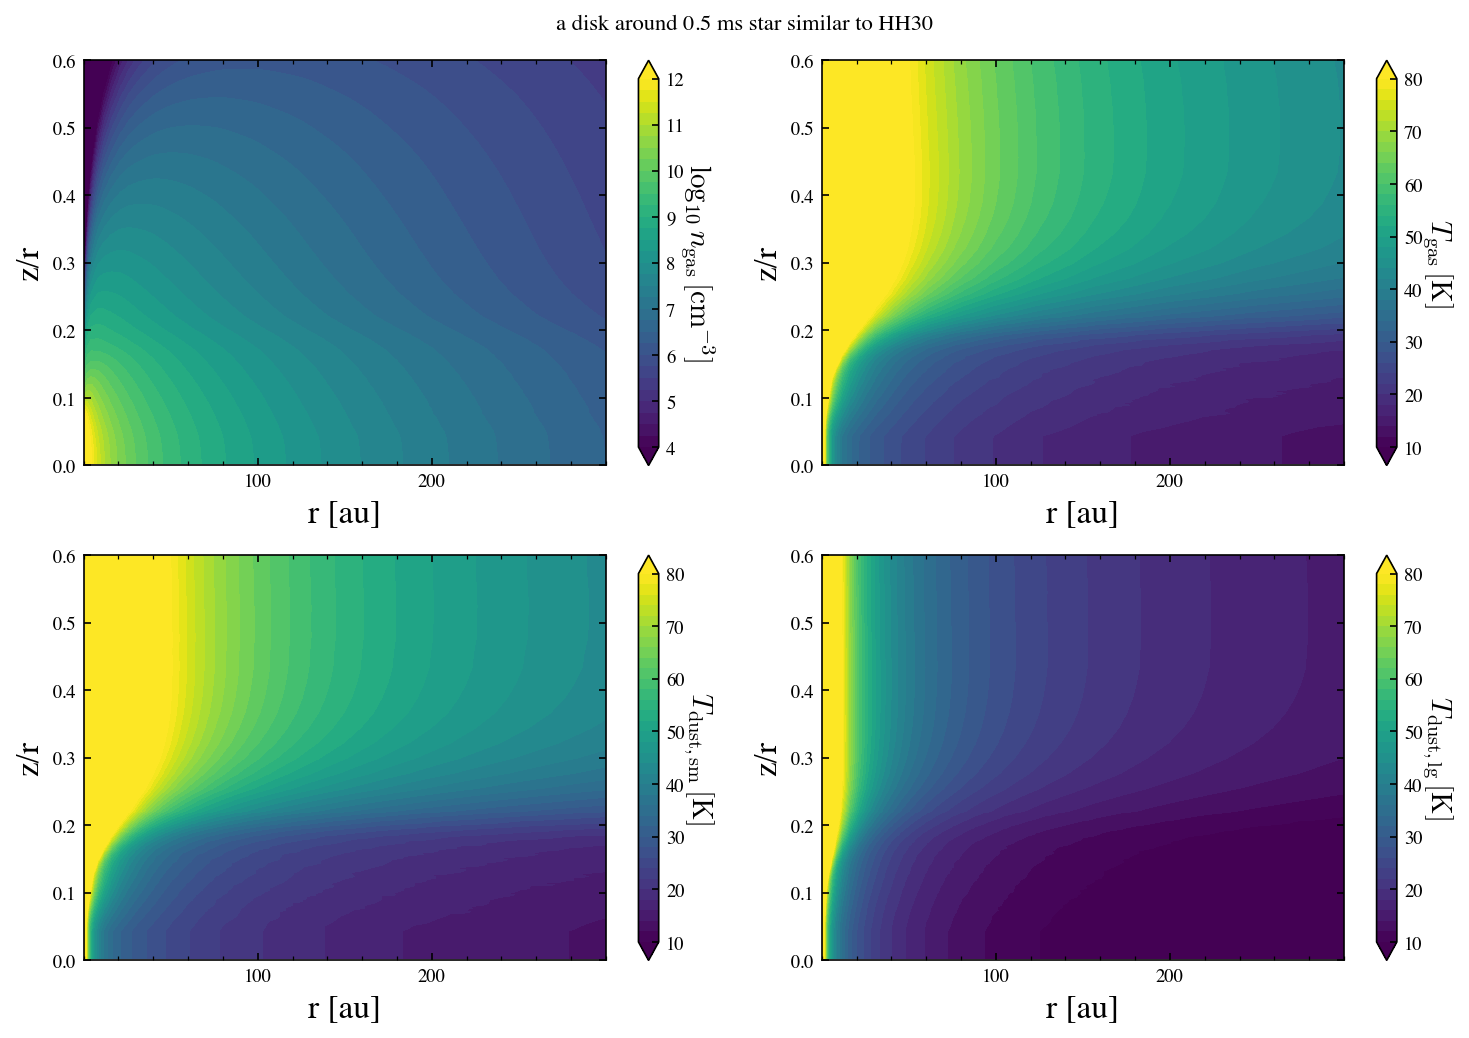

In [24]:
ncol = 2
nrow = 2

fig=plt.figure(dpi=150, figsize = (5*ncol, 3.5*nrow))

lim = np.arange(4, 12+0.25, 0.25) # 4, 18.1, 0.1
ticksrange = np.arange(4, 12+1, 1) # 4, 20, 2

lim_Tgas = np.arange(0, 3.5, 0.1)
ticksrange_Tgas = np.arange(0, 3.6, 0.6)

lim_linearTgas = np.arange(10, 80+2, 2)
ticksrange_linearTgas = np.arange(10, 80+10, 10)

cmap_selected = 'viridis' # 'jet' #'viridis'

######################################

# plt.subplot(nrow,ncol,1)
ax1 = ax = fig.add_subplot(nrow, ncol, 1)

# plt.title('Spherical Coordinate', fontsize = 12)

c = ax.contourf(rc/const.au, np.pi/2 - thetac, np.log10((rhogas[:,:,0]/const.mu).T), lim, zorder = 1, cmap = cmap_selected, extend = 'both')

cb = fig.colorbar(c, ticks=ticksrange, ax=ax)
cb.set_label(r'$\log_{10}{n_{\mathrm{gas}}}\,{\rm [cm^{-3}]}$', labelpad = 15, y = 0.5, rotation=270., fontsize = 14)

# ######################################

# plt.subplot(nrow,ncol,2)
ax2 = ax = fig.add_subplot(nrow, ncol, 2)

# plt.title('Spherical Coordinate', fontsize = 12)

c = ax.contourf(rc/const.au, np.pi/2 - thetac, (Tgas_0[:,:,0,0]).T, lim_linearTgas, zorder = 1, cmap = cmap_selected, extend = 'both')

cb = fig.colorbar(c, ticks=ticksrange_linearTgas, ax=ax)
cb.set_label(r'${T_{\mathrm{gas}}}\,{\rm [K]}$', labelpad = 15, y = 0.5, rotation=270., fontsize = 14)

# ######################################

# plt.subplot(nrow,ncol,2)
ax3 = ax = fig.add_subplot(nrow, ncol, 3)

# plt.title('Spherical Coordinate', fontsize = 12)

c = ax.contourf(rc/const.au, np.pi/2 - thetac, (Tdust[:,:,0,0]).T, lim_linearTgas, zorder = 1, cmap = cmap_selected, extend = 'both')

cb = fig.colorbar(c, ticks=ticksrange_linearTgas, ax=ax)
cb.set_label(r'${T_{\mathrm{dust,sm}}}\,{\rm [K]}$', labelpad = 15, y = 0.5, rotation=270., fontsize = 14)

# ######################################

# plt.subplot(nrow,ncol,2)
ax4 = ax = fig.add_subplot(nrow, ncol, 4)

# plt.title('Spherical Coordinate', fontsize = 12)

c = ax.contourf(rc/const.au, np.pi/2 - thetac, (Tdust[:,:,0,-1]).T, lim_linearTgas, zorder = 1, cmap = cmap_selected, extend = 'both')

cb = fig.colorbar(c, ticks=ticksrange_linearTgas, ax=ax)
cb.set_label(r'${T_{\mathrm{dust,lg}}}\,{\rm [K]}$', labelpad = 15, y = 0.5, rotation=270., fontsize = 14)


######################################

for ax in [ax1, ax2, ax3, ax4]:
    
    ax.set_xlabel('r [au]', fontsize = 16)
    ax.set_ylabel(r'z/r', fontsize = 16)
    # ax.set_xscale('log')

    ax.set_xlim(0, 300) 

    ax.set_xticks([100, 200])
    # Set the minor ticks every 20 units across the range 0 to 320
    minor_ticks = np.arange(0, 320, 20)
    ax.set_xticks(minor_ticks, minor=True)

    ax.set_ylim(0, 0.6)

######################################

plt.suptitle(model_name_in_figure)

fig.tight_layout()
plt.show()